<a href="https://colab.research.google.com/github/m22aie202/FM_GenAI/blob/main/m22aie202_Assignment_2_Attempt_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
!pip install datasets torchtext

In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import re
import numpy as np
from datasets import load_dataset
from collections import Counter
import matplotlib.pyplot as plt

In [25]:
#first 50,000 sentence pairs
dataset = load_dataset("OscarNav/spa-eng", split="train[:50000]")

In [26]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)
    return text

In [27]:
print(dataset[0])

{'eng': 'When the curtain went up, the stage was dark.', 'spa': 'Al levantarse el telón, la escena estaba oscura.'}


In [28]:
pairs = []

for item in dataset:
    en = clean_text(item["eng"])
    es = "[start] " + clean_text(item["spa"]) + " [end]"
    pairs.append((en, es))

In [29]:
#15,000 words and a maximum sequence length of 20 tokens
max_vocab = 15000
max_len = 20

counter = Counter()

for en, es in pairs:
    counter.update(en.split())
    counter.update(es.split())

vocab = ["<pad>", "<unk>"] + [word for word, _ in counter.most_common(max_vocab-2)]
word2idx = {w:i for i,w in enumerate(vocab)}
idx2word = {i:w for w,i in word2idx.items()}
vocab_size = len(vocab)

In [30]:
def encode(sentence):
    tokens = sentence.split()[:max_len]
    ids = [word2idx.get(t, word2idx["<unk>"]) for t in tokens]
    ids += [word2idx["<pad>"]] * (max_len - len(ids))
    return ids

In [31]:
data = [(encode(en), encode(es)) for en, es in pairs]

train_data = data[:45000]
val_data   = data[45000:50000]

In [32]:
def create_loader(dataset, batch_size=64):
    src = torch.tensor([x[0] for x in dataset])
    tgt = torch.tensor([x[1] for x in dataset])
    return torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(src, tgt),
        batch_size=batch_size,
        shuffle=True
    )

train_loader = create_loader(train_data)
val_loader   = create_loader(val_data)

In [33]:
class ScaledDotProductAttention(nn.Module):
    def forward(self, Q, K, V, mask=None):
        scores = torch.matmul(Q, K.transpose(-2,-1)) / math.sqrt(Q.size(-1))
        if mask is not None:
            scores = scores.masked_fill(mask==0, -1e9)
        attn = F.softmax(scores, dim=-1)
        return torch.matmul(attn, V)

In [34]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model=256, num_heads=4): # d_model of 256 and exactly 4 attention heads
        super().__init__()
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.fc  = nn.Linear(d_model, d_model)

    def split_heads(self, x):
        b, seq, d = x.size()
        x = x.view(b, seq, self.num_heads, self.d_k)
        return x.transpose(1,2)

    def forward(self, Q_input, K_input, V_input):
        Q = self.split_heads(self.W_q(Q_input))
        K = self.split_heads(self.W_k(K_input))
        V = self.split_heads(self.W_v(V_input))

        attn = ScaledDotProductAttention()(Q,K,V)

        attn = attn.transpose(1,2).contiguous()
        attn = attn.view(attn.size(0), -1, self.num_heads*self.d_k)

        return self.fc(attn)

In [35]:
class EncoderLayer(nn.Module):
    def __init__(self):
        super().__init__()
        self.self_attn = MultiHeadAttention()
        self.norm1 = nn.LayerNorm(256)
        self.ff = nn.Sequential(
            nn.Linear(256,512),
            nn.ReLU(),
            nn.Linear(512,256)
        )
        self.norm2 = nn.LayerNorm(256)

    def forward(self,x):
        x = self.norm1(x + self.self_attn(x,x,x))
        x = self.norm2(x + self.ff(x))
        return x

In [36]:
class DecoderLayer(nn.Module):
    def __init__(self):
        super().__init__()
        self.self_attn  = MultiHeadAttention()
        self.cross_attn = MultiHeadAttention()

        self.norm1 = nn.LayerNorm(256)
        self.norm2 = nn.LayerNorm(256)
        self.norm3 = nn.LayerNorm(256)

        self.ff = nn.Sequential(
            nn.Linear(256,512),
            nn.ReLU(),
            nn.Linear(512,256)
        )

    def forward(self,x,enc_out):
        x = self.norm1(x + self.self_attn(x,x,x))
        x = self.norm2(x + self.cross_attn(x,enc_out,enc_out))
        x = self.norm3(x + self.ff(x))
        return x

In [37]:
class Transformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(vocab_size,256)
        self.encoder = EncoderLayer()
        self.decoder = DecoderLayer()
        self.fc = nn.Linear(256,vocab_size)

    def forward(self,src,tgt):
        src = self.embed(src)
        tgt = self.embed(tgt)

        enc_out = self.encoder(src)
        dec_out = self.decoder(tgt, enc_out)

        return self.fc(dec_out)

In [38]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Transformer().to(device)

optimizer = torch.optim.Adam(model.parameters())
criterion = nn.CrossEntropyLoss(ignore_index=word2idx["<pad>"])

train_losses = []
val_losses = []

for epoch in range(20):
    model.train()
    total_loss = 0

    for src,tgt in train_loader:
        src,tgt = src.to(device), tgt.to(device)
        optimizer.zero_grad()

        output = model(src, tgt[:,:-1])
        loss = criterion(
            output.reshape(-1,vocab_size),
            tgt[:,1:].reshape(-1)
        )
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    train_losses.append(total_loss/len(train_loader))

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for src,tgt in val_loader:
            src,tgt = src.to(device), tgt.to(device)
            output = model(src,tgt[:,:-1])
            loss = criterion(
                output.reshape(-1,vocab_size),
                tgt[:,1:].reshape(-1)
            )
            val_loss += loss.item()

    val_losses.append(val_loss/len(val_loader))

    print(f"Epoch {epoch+1}: Train {train_losses[-1]:.4f}, Val {val_losses[-1]:.4f}")

Epoch 1: Train 3.8936, Val 2.6349
Epoch 2: Train 1.9092, Val 1.8733
Epoch 3: Train 1.1300, Val 1.6890
Epoch 4: Train 0.7793, Val 1.6617
Epoch 5: Train 0.6234, Val 1.6804
Epoch 6: Train 0.5336, Val 1.7364
Epoch 7: Train 0.4682, Val 1.7703
Epoch 8: Train 0.4165, Val 1.8392
Epoch 9: Train 0.3796, Val 1.8520
Epoch 10: Train 0.3492, Val 1.9258
Epoch 11: Train 0.3175, Val 1.9483
Epoch 12: Train 0.3002, Val 1.9752
Epoch 13: Train 0.2795, Val 2.0057
Epoch 14: Train 0.2705, Val 2.0365
Epoch 15: Train 0.2556, Val 2.0429
Epoch 16: Train 0.2470, Val 2.0648
Epoch 17: Train 0.2323, Val 2.0598
Epoch 18: Train 0.2272, Val 2.1010
Epoch 19: Train 0.2193, Val 2.1110
Epoch 20: Train 0.2087, Val 2.1108


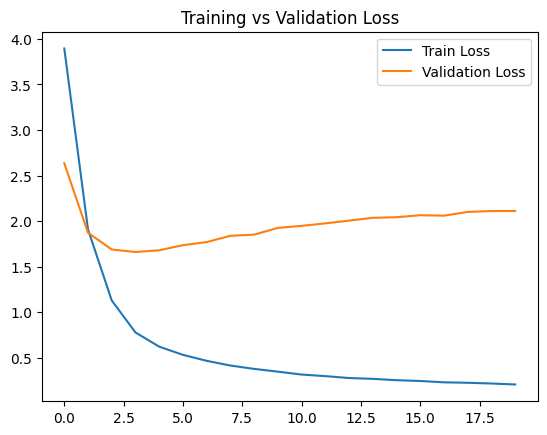

In [39]:
plt.plot(train_losses,label="Train Loss")
plt.plot(val_losses,label="Validation Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

In [40]:
def greedy_decode(model, src_sentence):
    model.eval()
    src = torch.tensor([encode(src_sentence)]).to(device)
    generated = [word2idx["[start]"]]

    for _ in range(max_len):
        tgt = torch.tensor([generated]).to(device)
        output = model(src,tgt)
        next_token = output.argmax(-1)[:,-1].item()
        generated.append(next_token)
        if idx2word[next_token] == "[end]":
            break

    return " ".join([idx2word[i] for i in generated])

In [41]:
for i in range(5):
    src = pairs[45000+i][0]
    tgt = pairs[45000+i][1]
    pred = greedy_decode(model, src)

    print("Source English:", src)
    print("Target Spanish:", tgt)
    print("Model Prediction:", pred)
    print("-"*50)

Source English: tom was a judge in an art contest
Target Spanish: [start] tom fue juez en un concurso de arte [end]
Model Prediction: [start] perro perro perro perro perro perro perro perro perro perro perro perro perro perro perro perro perro perro perro perro
--------------------------------------------------
Source English: its my umbrella
Target Spanish: [start] es mi paraguas [end]
Model Prediction: [start] abajo abajo abajo abajo abajo abajo abajo abajo abajo abajo abajo abajo abajo abajo abajo abajo abajo abajo abajo abajo
--------------------------------------------------
Source English: you may choose whichever you want
Target Spanish: [start] tú puedes elegir la que quieras [end]
Model Prediction: [start] perro perro perro perro perro perro perro perro perro perro perro perro perro perro perro perro perro perro perro perro
--------------------------------------------------
Source English: i cant eat the apple
Target Spanish: [start] no puedo comerme la manzana [end]
Model Pre